In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df=pd.read_csv('/kaggle/input/competitions/titanic/train.csv')[['PassengerId','Age','Fare','Survived']]

In [33]:
df.head()

,PassengerId,Age,Fare,Survived,age_mean,age_median
0,1,22.0,7.2500,0,22.0,22.0
1,2,38.0,71.2833,1,38.0,38.0
2,3,26.0,7.9250,1,26.0,26.0
3,4,35.0,53.1000,1,35.0,35.0
4,5,35.0,8.0500,0,35.0,35.0


In [13]:
df.isnull().sum()

PassengerId      0
Age            177
Fare             0
Survived         0
dtype: int64

### Now the age column has missing values , now try to fill using an Univarient Imputation using Pandas as Scikit learn

In [15]:
df['Age'].var()

211.0191247463081

In [18]:
df['Age'].corr(df['Survived'])

np.float64(-0.07722109457217768)

<Axes: ylabel='Frequency'>

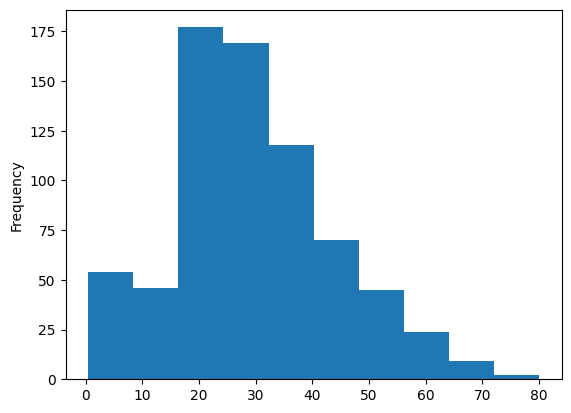

In [21]:
df['Age'].plot(kind='hist')

In [32]:
df['age_mean']=df['Age'].fillna(df['Age'].mean())
df['age_median']=df['Age'].fillna(df['Age'].median())

<Axes: ylabel='Density'>

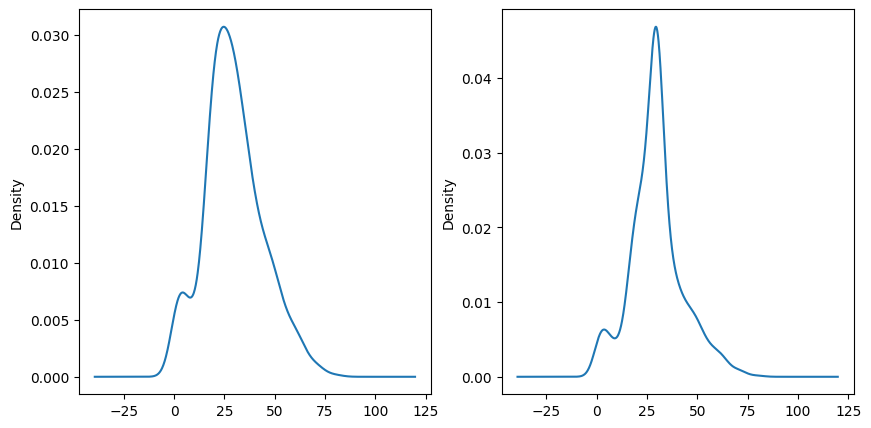

In [34]:
plt.figure(figsize=(10,5))
plt.subplot(121)

df['Age'].plot(kind='kde')

plt.subplot(122)
df['age_mean'].plot(kind='kde')

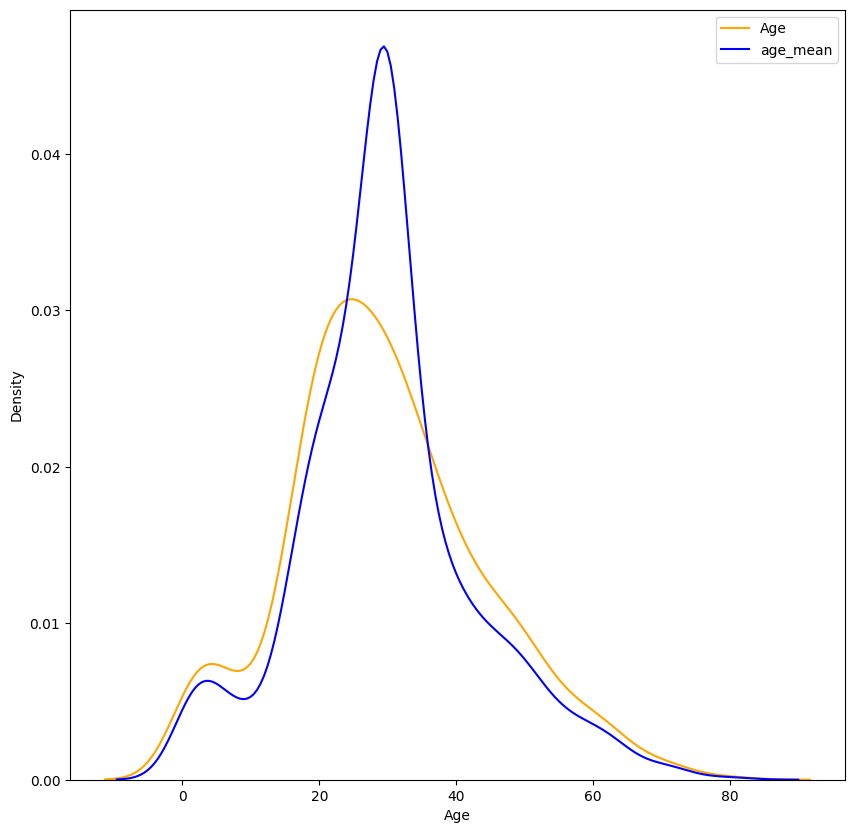

In [57]:
plt.figure(figsize=(10,10))
plt.subplot(111)
sns.kdeplot(x=df['Age'],color='orange',label='Age')
sns.kdeplot(x=df['age_mean'],color='blue',label='age_mean')
plt.legend(loc='upper right')
plt.show()

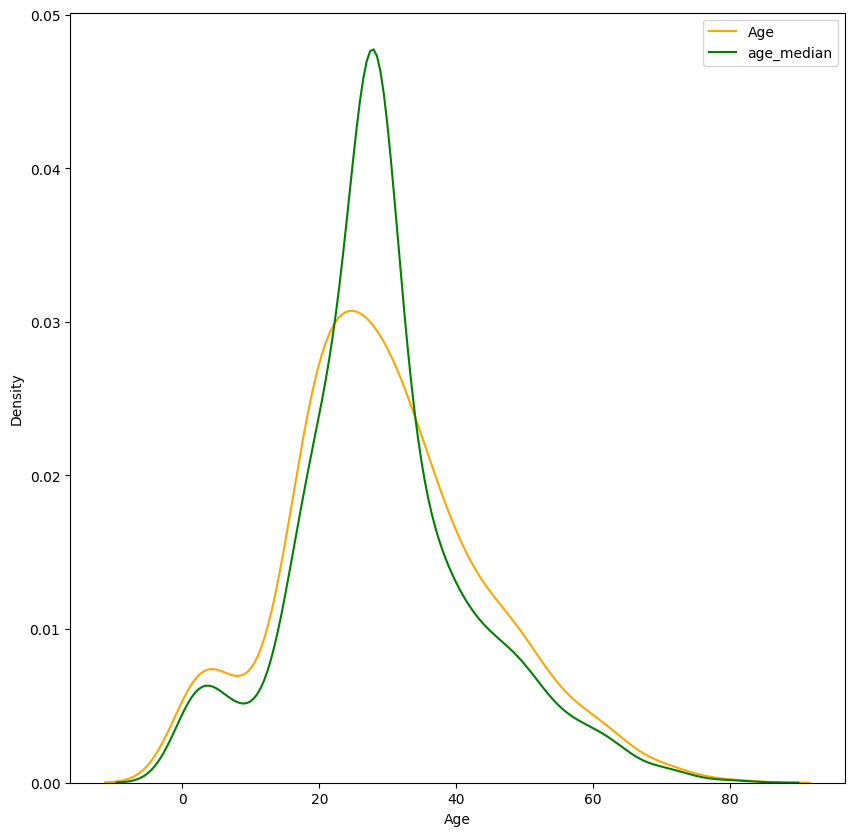

In [62]:
plt.figure(figsize=(10,10))
plt.subplot(111)
sns.kdeplot(x=df['Age'],color='orange',label='Age')


sns.kdeplot(x=df['age_median'],color='green',label='age_median')
plt.legend(loc='upper right')
plt.show()

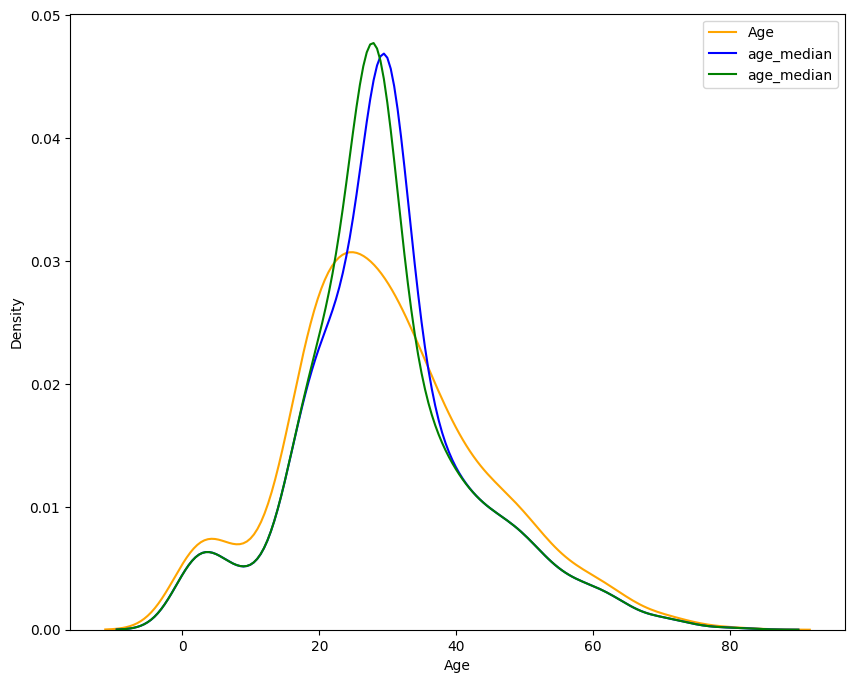

In [83]:
plt.figure(figsize=(10,8))
plt.subplot(111)
sns.kdeplot(x=df['Age'],color='orange',label='Age')

sns.kdeplot(df['age_mean'],color='blue',label='age_median')
sns.kdeplot(x=df['age_median'],color='green',label='age_median')
plt.legend(loc='upper right')
plt.show()

In [63]:
# Now see that , how much make the difference betwieen the data distribution , its may affect our machine 
# Learning Model , And do the issue in the future , and one more issue is when you deploy this model on the
# server then its not possible to handle the nan or missing values so we use the SimpleImputer() Provided 
# by the sklearn so lets implement this

In [64]:
from sklearn.model_selection import train_test_split

x=df[['PassengerId','Fare','Age']]
y=df['Survived']

In [65]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [75]:
x_train.shape,x_test.shape

((712, 3), (179, 3))

In [68]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

si=SimpleImputer(strategy='mean')

trf=ColumnTransformer([
    ('si',si,['Age'])
],remainder='passthrough')

In [69]:
trf.fit(x_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('si', SimpleImputer(), ['Age'])])

In [70]:
x_train = trf.transform(x_train)
x_test=trf.transform(x_test)

In [72]:
x_train

array([[ 31.        , 691.        ,  57.        ],
       [ 26.        , 890.        ,  30.        ],
       [ 21.        , 625.        ,  16.1       ],
       ...,
       [ 29.62641208, 348.        ,  16.1       ],
       [ 54.        , 775.        ,  23.        ],
       [ 29.        ,  67.        ,  10.5       ]])

In [73]:
x_test

array([[ 41.        , 273.        ,  19.5       ],
       [ 41.        , 639.        ,  39.6875    ],
       [ 38.        , 717.        , 227.525     ],
       [ 30.        , 245.        ,   7.225     ],
       [ 48.        , 755.        ,  65.        ],
       [ 28.        , 314.        ,   7.8958    ],
       [  6.        , 721.        ,  33.        ],
       [ 33.        , 873.        ,   5.        ],
       [ 27.        , 718.        ,  10.5       ],
       [ 28.        , 884.        ,  10.5       ],
       [ 20.        , 841.        ,   7.925     ],
       [ 29.62641208, 305.        ,   8.05      ],
       [  9.        , 166.        ,  20.525     ],
       [ 15.        , 831.        ,  14.4542    ],
       [ 27.        , 887.        ,  13.        ],
       [ 40.        ,  31.        ,  27.7208    ],
       [ 30.        , 419.        ,  13.        ],
       [ 19.        , 144.        ,   6.75      ],
       [ 29.62641208, 693.        ,  56.4958    ],
       [ 27.        , 147.     

In [78]:
np.isnan(x_train).sum()

np.int64(0)

In [79]:
np.isnan(x_test).sum()

np.int64(0)

In [80]:
x_train.shape

(712, 3)

In [81]:
x_test.shape

(179, 3)